In [1]:

import pandas as pd

In [2]:


url = "https://raw.githubusercontent.com/DataScience75/Top_mentor_projects_Datasets/main/9.2%20car-sales-missing-data.csv"

data = pd.read_csv(url)

data.head(2)

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"


In [4]:
#create a copy org the data
df = data.copy()
print(df)

     Make Colour  Odometer  Doors    Price
0  Toyota  White  150043.0    4.0   $4,000
1   Honda    Red   87899.0    4.0   $5,000
2  Toyota   Blue       NaN    3.0   $7,000
3     BMW  Black   11179.0    5.0  $22,000
4  Nissan  White  213095.0    4.0   $3,500
5  Toyota  Green       NaN    4.0   $4,500
6   Honda    NaN       NaN    4.0   $7,500
7   Honda   Blue       NaN    4.0      NaN
8  Toyota  White   60000.0    NaN      NaN
9     NaN  White   31600.0    4.0   $9,700


In [5]:
print("Missiong values - ")
print(df.isnull().sum())


Missiong values - 
Make        1
Colour      1
Odometer    4
Doors       1
Price       2
dtype: int64


In [6]:
## calculate the percentage missing 
## (number of missing values / total number of values)*100
total_rows = df.shape[0]  # 0 -> rows and 1 -> columns
missing_percent = (df.isnull().sum() / total_rows)*100
print(missing_percent)



Make        10.0
Colour      10.0
Odometer    40.0
Doors       10.0
Price       20.0
dtype: float64


In [7]:
df.shape

(10, 5)

In [8]:
## #how to impute the mission records 15 - 20%
# 1st method - drop
#df.dropna() is used to remove missing (NaN/null) values from a DataFrame.
df.dropna()


,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


In [9]:
## filling 0 where NA/null
df.fillna(0)   ##  fill 0 all columns  isko print karna h to niche wala ko comment karo 
## for specific columns only
df[['Odometer','Doors','Price']].fillna(0)

,Odometer,Doors,Price
0,150043.0,4.0,"$4,000"
1,87899.0,4.0,"$5,000"
2,0.0,3.0,"$7,000"
3,11179.0,5.0,"$22,000"
4,213095.0,4.0,"$3,500"
5,0.0,4.0,"$4,500"
6,0.0,4.0,"$7,500"
7,0.0,4.0,0
8,60000.0,0.0,0
9,31600.0,4.0,"$9,700"


In [10]:
## avg of any column values
print(df['Odometer'].mean())

92302.66666666667


In [11]:
df['Odometer'].sum()

np.float64(553816.0)

In [12]:
df[['Odometer','Doors']].mean()

Odometer    92302.666667
Doors           4.000000
dtype: float64

In [13]:
#remove the $ sign from the price column
df['Price'] = df['Price'].str.replace('$', '', regex=False)

In [14]:
df['Price']

0     4,000
1     5,000
2     7,000
3    22,000
4     3,500
5     4,500
6     7,500
7       NaN
8       NaN
9     9,700
Name: Price, dtype: object

In [16]:
df['Doors'].median()

4.0

In [18]:
df['Make']    
# null/NaN fill the front ke liye .ffill() i.e uske just before wala name fill hoga aur bad wal fill ke liye back .bfill()
df['Make'].ffill()

0    Toyota
1     Honda
2    Toyota
3       BMW
4    Nissan
5    Toyota
6     Honda
7     Honda
8    Toyota
9    Toyota
Name: Make, dtype: object

In [20]:
## back wala fill
df['Colour']  # check col to analysis  
#NaN ke jagah Blue fill ho jayega 
df['Colour'].bfill()

0    White
1      Red
2     Blue
3    Black
4    White
5    Green
6     Blue
7     Blue
8    White
9    White
Name: Colour, dtype: object

In [25]:
## seaborn for graphs and visaulisation
## install first 
!pip install seaborn

In [31]:

import seaborn as sb
import pandas as pd

In [28]:
## read the car sales csv data 
# -- check if there is any missing value or not 
# -- treat the missing values
#-- clean the dataif anything required for cleaning 



In [33]:
car_sales = pd.read_csv("https://raw.githubusercontent.com/DataScience75/Top_mentor_projects_Datasets/refs/heads/main/Car_sales.csv")
car_sales.head

<bound method NDFrame.head of     Manufacturer    Model  Sales_in_thousands  __year_resale_value  \
0          Acura  Integra              16.919               16.360   
1          Acura       TL              39.384               19.875   
2          Acura       CL              14.114               18.225   
3          Acura       RL               8.588               29.725   
4           Audi       A4              20.397               22.255   
..           ...      ...                 ...                  ...   
152        Volvo      V40               3.545                  NaN   
153        Volvo      S70              15.245                  NaN   
154        Volvo      V70              17.531                  NaN   
155        Volvo      C70               3.493                  NaN   
156        Volvo      S80              18.969                  NaN   

    Vehicle_type  Price_in_thousands  Engine_size  Horsepower  Wheelbase  \
0      Passenger               21.50          1.8    

In [42]:
## rename column syntax
##  car_sales.rename(columns = {'old col name':'new col name'}, inplace = True) ## parmanently change

car_sales['Sales_in_thousands'].sum()  # 8320.698
var = car_sales[['Sales_in_thousands']].fillna(0)      ## double [[]] use karne se column name ke sath print hota h 
var



,Sales_in_thousands
0,16.919
1,39.384
2,14.114
3,8.588
4,20.397
...,...
152,3.545
153,15.245
154,17.531
155,3.493


In [52]:
## manufacturer by sales 
car_sales.groupby('Manufacturer')['Sales_in_thousands'].sum()

Manufacturer
Acura           79.005
Audi            40.557
BMW             46.505
Buick          242.019
Cadillac       112.178
Chevrolet      554.365
Chrysler       201.721
Dodge          910.149
Ford          2022.635
Honda          592.674
Hyundai        137.326
Infiniti        23.713
Jaguar          15.467
Jeep           293.153
Lexus          106.843
Lincoln         85.634
Mercedes-B     117.125
Mercury        237.999
Mitsubishi     180.895
Nissan         399.635
Oldsmobile     178.989
Plymouth        64.001
Pontiac        370.534
Porsche         12.128
Saab            21.306
Saturn         168.850
Subaru          80.135
Toyota         740.205
Volkswagen     209.212
Volvo           75.740
Name: Sales_in_thousands, dtype: float64

<Axes: xlabel='Sales_in_thousands', ylabel='Manufacturer'>

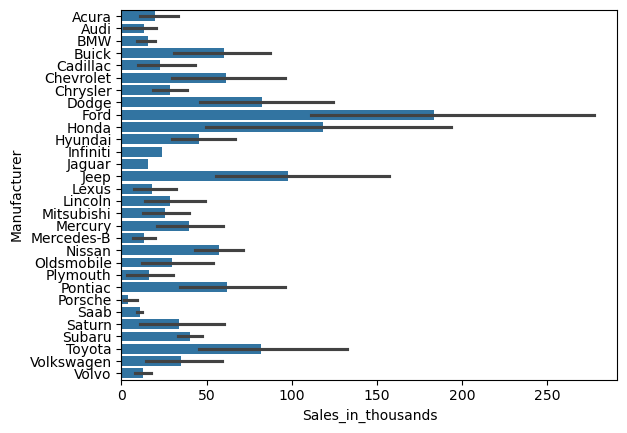

In [57]:
## graph representation of this 
sb.barplot(y = 'Manufacturer', x = 'Sales_in_thousands', data = car_sales)    ## barplot the type of graph